# O01_ef35 histinit visualization

60年前の実データ水準を初期値にした 60 年パスと、12個の約5年チャンクを確認する notebook です。

In [28]:
from pathlib import Path

ROOT = Path(r"/home/u00121/graph_ssm_abm/ZA_goal09_variant_ZA_minimal_final/results_fix4_7/O01_ef35/histinit")
PATH60 = ROOT / "60y_paths"
PATH5 = ROOT / "5y_paths"
REAL_PATH = Path("/home/u00121/output.csv")

print("Path setup OK")
print("ROOT:", ROOT)


Path setup OK
ROOT: /home/u00121/graph_ssm_abm/ZA_goal09_variant_ZA_minimal_final/results_fix4_7/O01_ef35/histinit


In [29]:
import numpy as np
print("numpy OK")
import pandas as pd
print("pandas OK")
import matplotlib.pyplot as plt
print("matplotlib OK")

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print("60y files:", len(list(PATH60.glob("generated_paths_seed*.csv"))))
print("5y files:", len(list(PATH5.glob("generated_paths_seed*-*.csv"))))


numpy OK
pandas OK
matplotlib OK
60y files: 10
5y files: 120


## 対象 seed / chunk の指定

In [30]:

# ここを変更すると、見る seed / 5年分割番号を切り替えられます
SEED = "seed01"   # seed01 ... seed10
CHUNK = 1         # 1 ... 12
ROLLING_CORR_WINDOW = 90
ROLLING_VOL_WINDOW = 21

def load_generated(seed=SEED, chunk=CHUNK):
    df60 = pd.read_csv(PATH60 / f"generated_paths_{seed}.csv", parse_dates=["Date"])
    df5 = pd.read_csv(PATH5 / f"generated_paths_{seed}-{chunk}.csv", parse_dates=["Date"])
    return df60, df5

def load_real_tail(n):
    real = pd.read_csv(REAL_PATH, parse_dates=["Date"])
    if len(real) >= n:
        real = real.tail(n).reset_index(drop=True)
    return real

df60, df5 = load_generated()
real60 = load_real_tail(len(df60))
print(SEED, "60y", df60.shape, "5y chunk", CHUNK, df5.shape)
df60.head()


seed01 60y (14882, 6) 5y chunk 1 (1241, 6)


,path_id,Date,sp500_abs,DGS10_abs,sp500,DGS10
0,0,1966-01-05,94.542165,4.630000,0.018225,0.040124
1,0,1966-01-06,95.365069,4.742555,0.008704,0.072431
2,0,1966-01-07,97.297125,4.768042,0.020260,0.025487
3,0,1966-01-10,96.088819,4.775052,-0.012419,0.007010
4,0,1966-01-11,96.175230,4.770781,0.000899,-0.004272


## 10本の60年パス一覧

In [31]:

rows = []
for p in sorted(PATH60.glob("generated_paths_seed*.csv")):
    d = pd.read_csv(p, parse_dates=["Date"])
    sp_col = "sp500_abs" if "sp500_abs" in d.columns else "sp500"
    dgs_col = "DGS10_abs" if "DGS10_abs" in d.columns else "DGS10"
    rows.append({
        "file": p.name,
        "n": len(d),
        "start": d["Date"].iloc[0].date(),
        "end": d["Date"].iloc[-1].date(),
        "sp500_level_start": d[sp_col].iloc[0],
        "sp500_level_end": d[sp_col].iloc[-1],
        "DGS10_level_start": d[dgs_col].iloc[0],
        "DGS10_level_end": d[dgs_col].iloc[-1],
    })
summary = pd.DataFrame(rows)
summary


,file,n,start,end,sp500_level_start,sp500_level_end,DGS10_level_start,DGS10_level_end
0,generated_paths_seed01.csv,14882,1966-01-05,2026-05-14,94.542165,5366.247135,4.63,8.931929
1,generated_paths_seed02.csv,14882,1966-01-05,2026-05-14,94.686504,8413.241663,4.63,11.292729
2,generated_paths_seed03.csv,14882,1966-01-05,2026-05-14,92.672410,6231.350862,4.63,13.088076
3,generated_paths_seed04.csv,14882,1966-01-05,2026-05-14,95.275969,7540.201762,4.63,4.859292
4,generated_paths_seed05.csv,14882,1966-01-05,2026-05-14,93.884320,10937.502996,4.63,2.847593
5,generated_paths_seed06.csv,14882,1966-01-05,2026-05-14,93.003473,10471.402072,4.63,4.009450
6,generated_paths_seed07.csv,14882,1966-01-05,2026-05-14,93.656397,17281.688700,4.63,15.561948
7,generated_paths_seed08.csv,14882,1966-01-05,2026-05-14,94.049464,15180.866096,4.63,5.981753
8,generated_paths_seed09.csv,14882,1966-01-05,2026-05-14,93.606388,8673.155864,4.63,11.241088
9,generated_paths_seed10.csv,14882,1966-01-05,2026-05-14,92.529797,12482.958617,4.63,4.163351


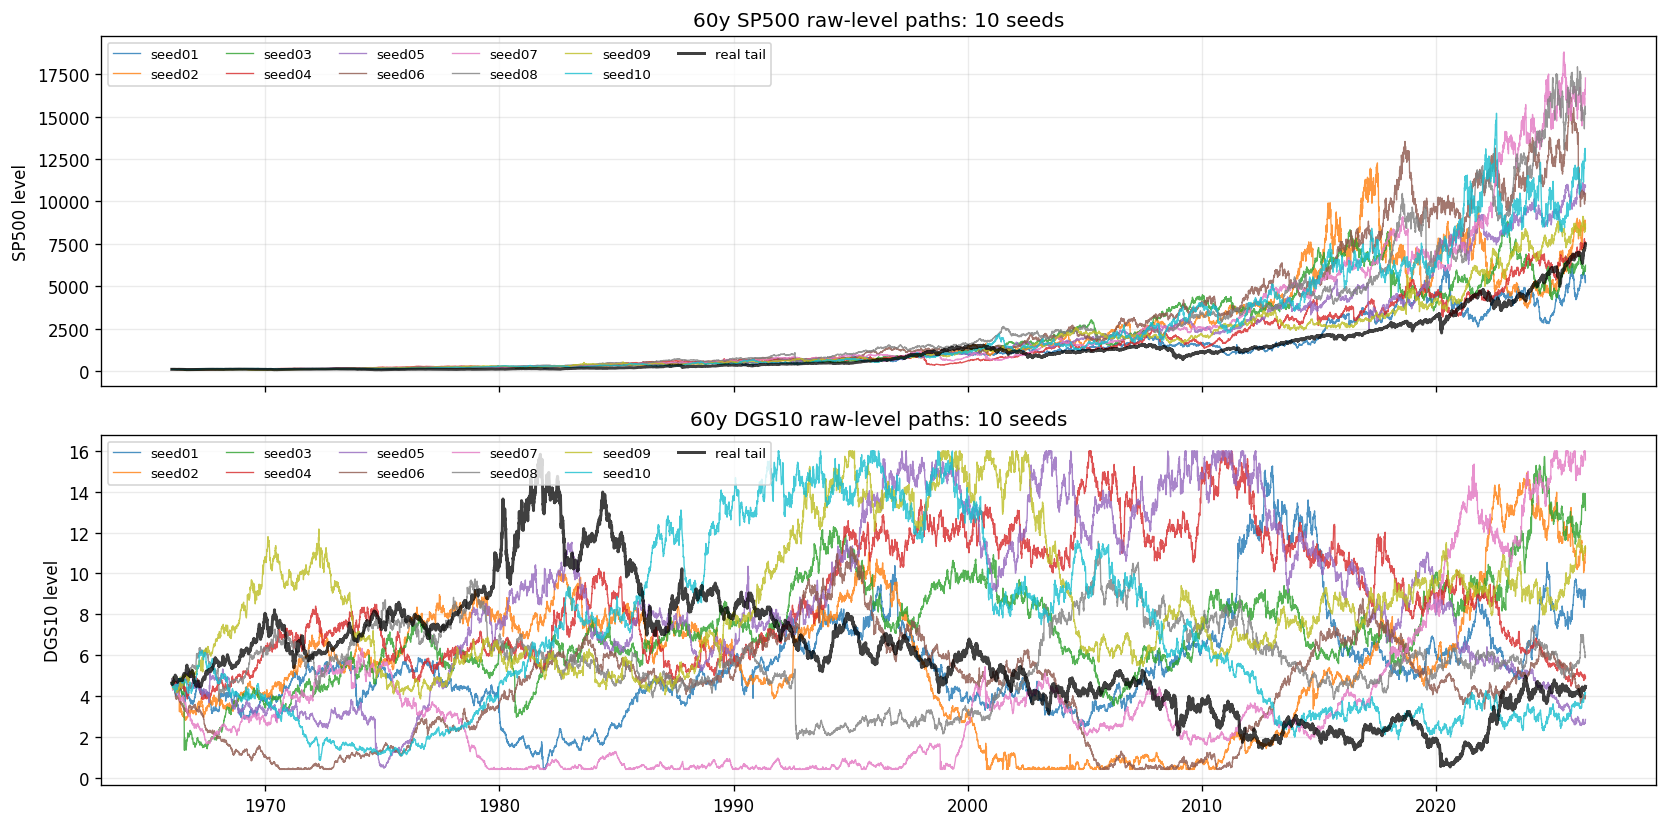

In [32]:

def value_col(df, base):
    """histinit CSV は *_abs が水準、base列がリターン/変化量の場合がある。"""
    abs_col = f"{base}_abs"
    return abs_col if abs_col in df.columns else base

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for p in sorted(PATH60.glob("generated_paths_seed*.csv")):
    d = pd.read_csv(p, parse_dates=["Date"])
    sp_col = value_col(d, "sp500")
    dgs_col = value_col(d, "DGS10")
    label = p.stem.replace("generated_paths_", "")
    axes[0].plot(d["Date"], d[sp_col], lw=0.8, alpha=0.8, label=label)
    axes[1].plot(d["Date"], d[dgs_col], lw=0.8, alpha=0.8, label=label)

if REAL_PATH.exists():
    r = load_real_tail(len(df60))
    real_sp_col = value_col(r, "sp500")
    real_dgs_col = value_col(r, "DGS10")
    axes[0].plot(df60["Date"], r[real_sp_col].to_numpy(), color="black", lw=1.8, alpha=0.75, label="real tail")
    axes[1].plot(df60["Date"], r[real_dgs_col].to_numpy(), color="black", lw=1.8, alpha=0.75, label="real tail")

axes[0].set_title("60y SP500 raw-level paths: 10 seeds")
axes[1].set_title("60y DGS10 raw-level paths: 10 seeds")
axes[0].set_ylabel("SP500 level")
axes[1].set_ylabel("DGS10 level")
axes[0].legend(ncol=6, fontsize=8)
axes[1].legend(ncol=6, fontsize=8)
plt.tight_layout()
plt.show()


## 選択した60年パスの詳細

subplot で詰めず、横長の単独図として表示します。SP500/DGS10 の raw level には実データも重ねています。90d rolling corr は正を赤、負を青で塗っています。


seed01: 60y histinit raw path


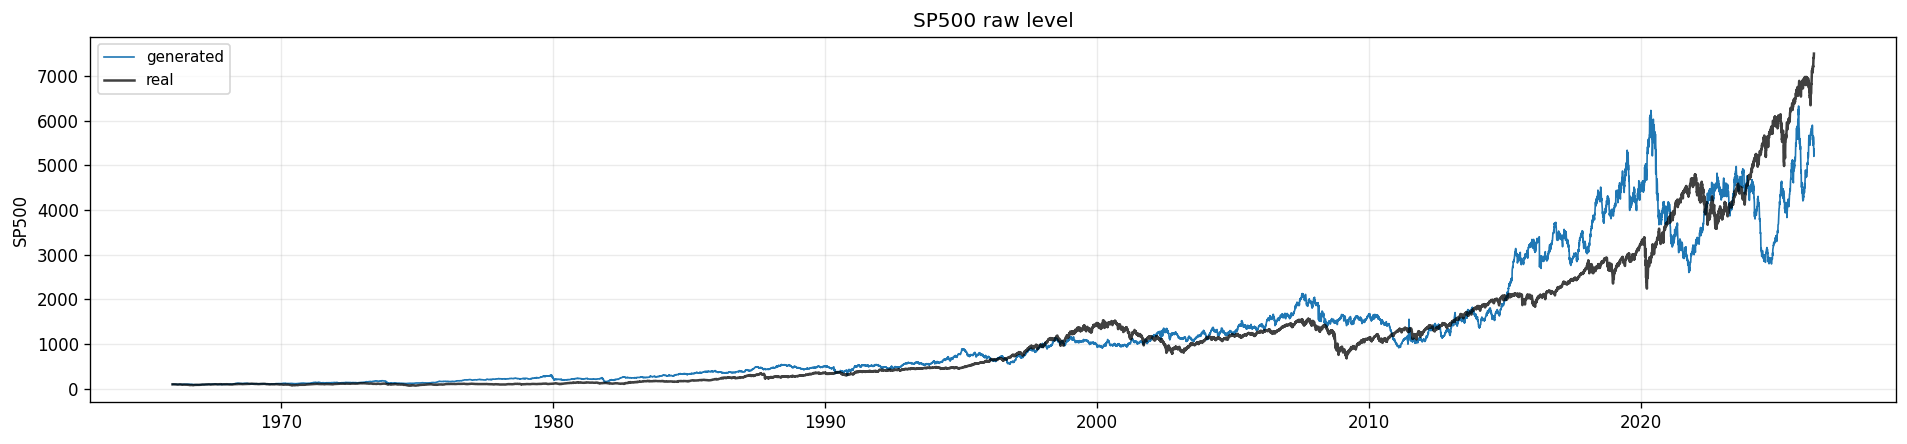

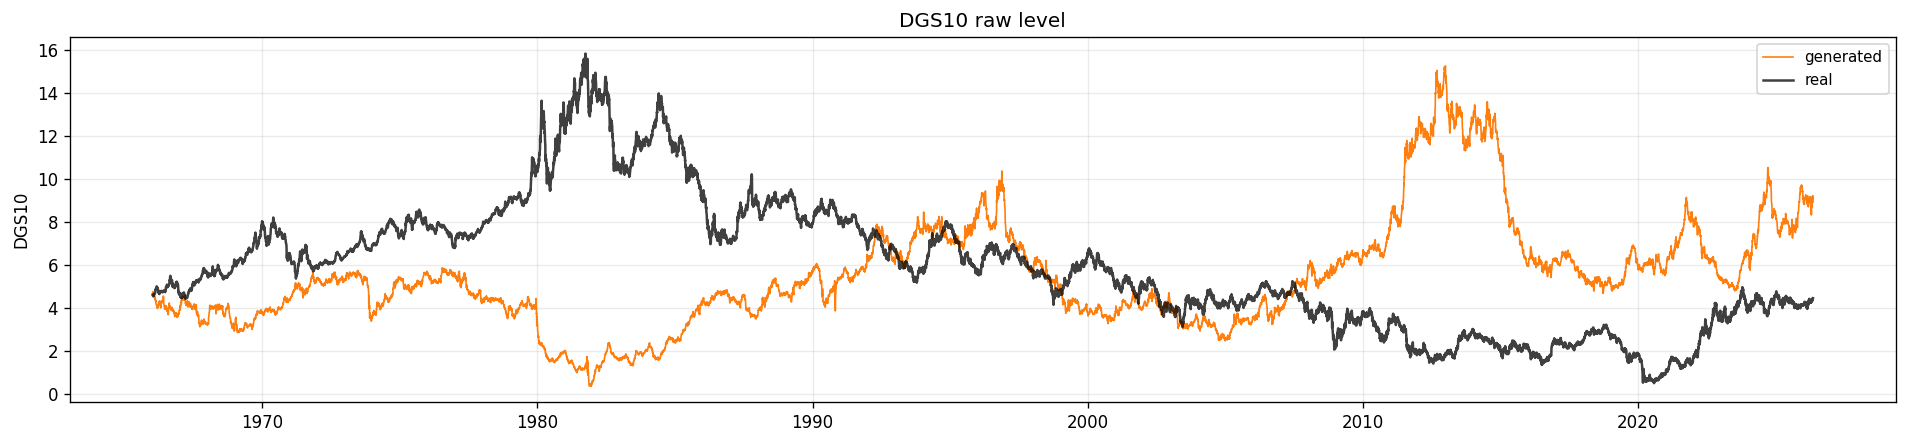

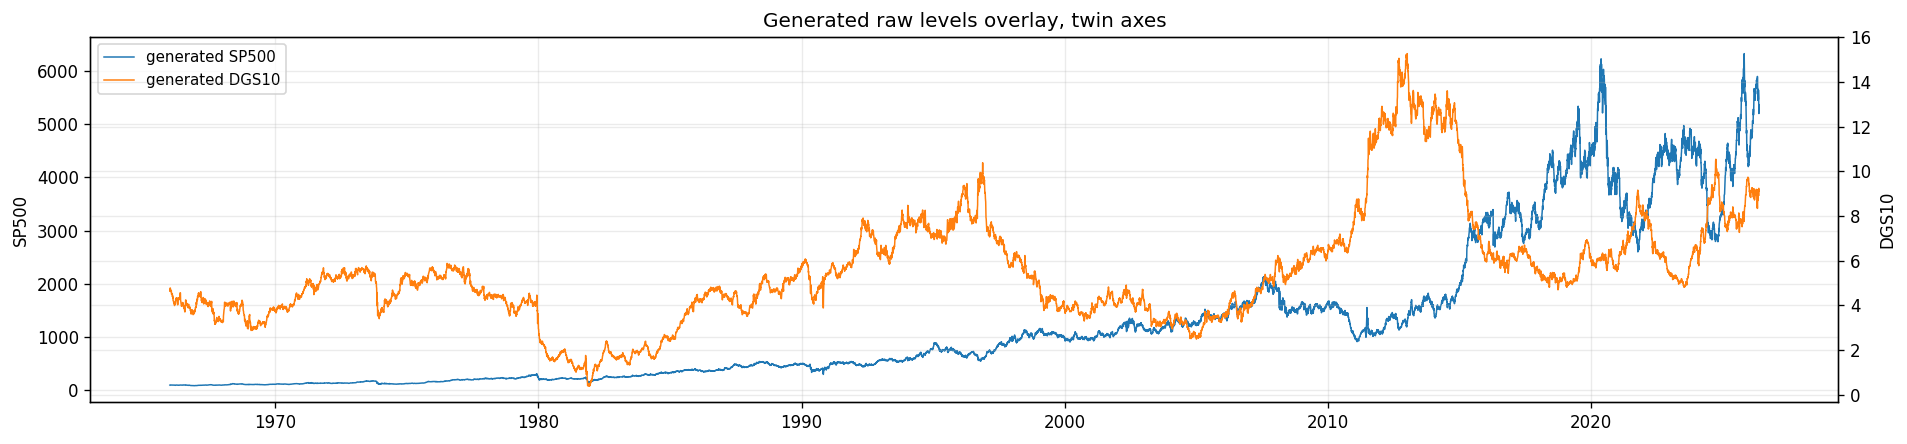

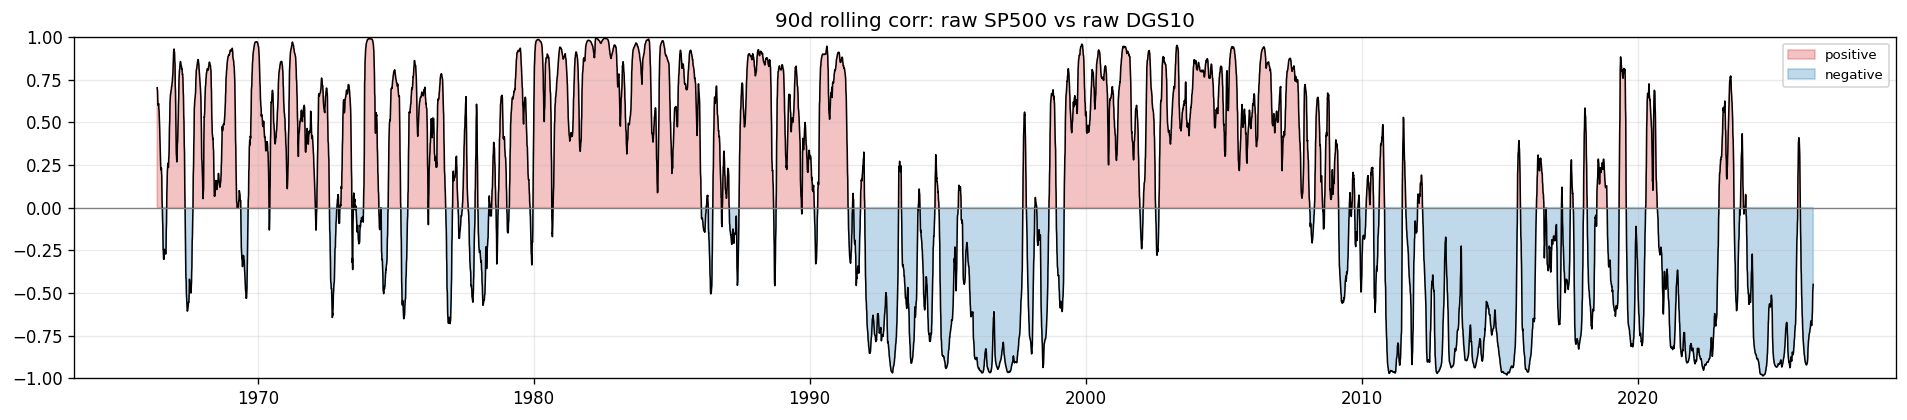

In [33]:

def value_col(df, base):
    """histinit/output CSV は *_abs が水準、base列がリターン/変化量の場合がある。"""
    abs_col = f"{base}_abs"
    return abs_col if abs_col in df.columns else base

def sp_level(df):
    return df[value_col(df, "sp500")]

def dgs_level(df):
    return df[value_col(df, "DGS10")]

def sp_return(df):
    # 水準列がある場合は水準から log return を再計算する。
    return np.log(sp_level(df)).diff()

def dgs_change(df):
    # 水準列がある場合は水準から差分を再計算する。
    return dgs_level(df).diff()

def real_aligned(df):
    """表示対象 df と同じ Date を持つ実データを返す。なければ空 DataFrame。"""
    if not REAL_PATH.exists():
        return pd.DataFrame()
    real = pd.read_csv(REAL_PATH, parse_dates=["Date"])
    keep = ["Date"]
    for c in ["sp500_abs", "DGS10_abs", "sp500", "DGS10"]:
        if c in real.columns:
            keep.append(c)
    return df[["Date"]].merge(real[keep], on="Date", how="left")

def plot_rolling_corr_wide(df, window=90, title="90d rolling corr: SP500 level vs DGS10"):
    rc = sp_level(df).rolling(window).corr(dgs_level(df))
    x = df["Date"]
    fig, ax = plt.subplots(figsize=(16, 3.6))
    ax.plot(x, rc, color="black", lw=0.9)
    ax.fill_between(x, rc, 0, where=(rc > 0), color="tab:red", alpha=0.28, interpolate=True, label="positive")
    ax.fill_between(x, rc, 0, where=(rc < 0), color="tab:blue", alpha=0.28, interpolate=True, label="negative")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()
    return rc

def plot_raw_path_overview(df, title):
    """パス確認用: subplot で詰めず、横長の単独図を順番に表示する。"""
    sp = sp_level(df)
    dgs = dgs_level(df)
    real = real_aligned(df)
    has_real = len(real) > 0 and real[value_col(real, "sp500")].notna().any()

    print(title)

    fig, ax = plt.subplots(figsize=(16, 3.8))
    ax.plot(df["Date"], sp, color="tab:blue", lw=1.0, label="generated")
    if has_real:
        ax.plot(df["Date"], real[value_col(real, "sp500")], color="black", lw=1.5, alpha=0.75, label="real")
    ax.set_title("SP500 raw level")
    ax.set_ylabel("SP500")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 3.8))
    ax.plot(df["Date"], dgs, color="tab:orange", lw=1.0, label="generated")
    if has_real:
        ax.plot(df["Date"], real[value_col(real, "DGS10")], color="black", lw=1.5, alpha=0.75, label="real")
    ax.set_title("DGS10 raw level")
    ax.set_ylabel("DGS10")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 3.8))
    ax2 = ax.twinx()
    ax.plot(df["Date"], sp, color="tab:blue", lw=0.9, label="generated SP500")
    ax2.plot(df["Date"], dgs, color="tab:orange", lw=0.9, label="generated DGS10")
    ax.set_title("Generated raw levels overlay, twin axes")
    ax.set_ylabel("SP500")
    ax2.set_ylabel("DGS10")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    plot_rolling_corr_wide(df, ROLLING_CORR_WINDOW, f"{ROLLING_CORR_WINDOW}d rolling corr: raw SP500 vs raw DGS10")

plot_raw_path_overview(df60, f"{SEED}: 60y histinit raw path")


## 選択した5年チャンクの詳細

こちらも横長の単独図として表示し、raw level には同期間の実データを重ねています。


seed01: 5y chunk 1 raw path


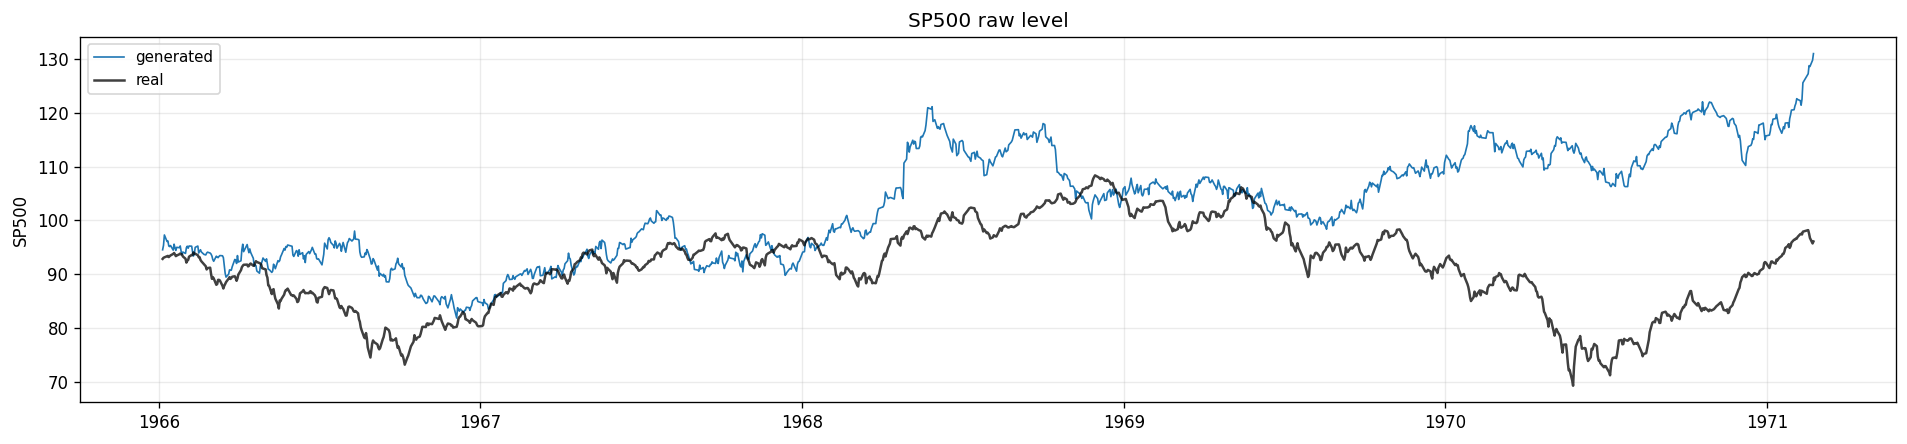

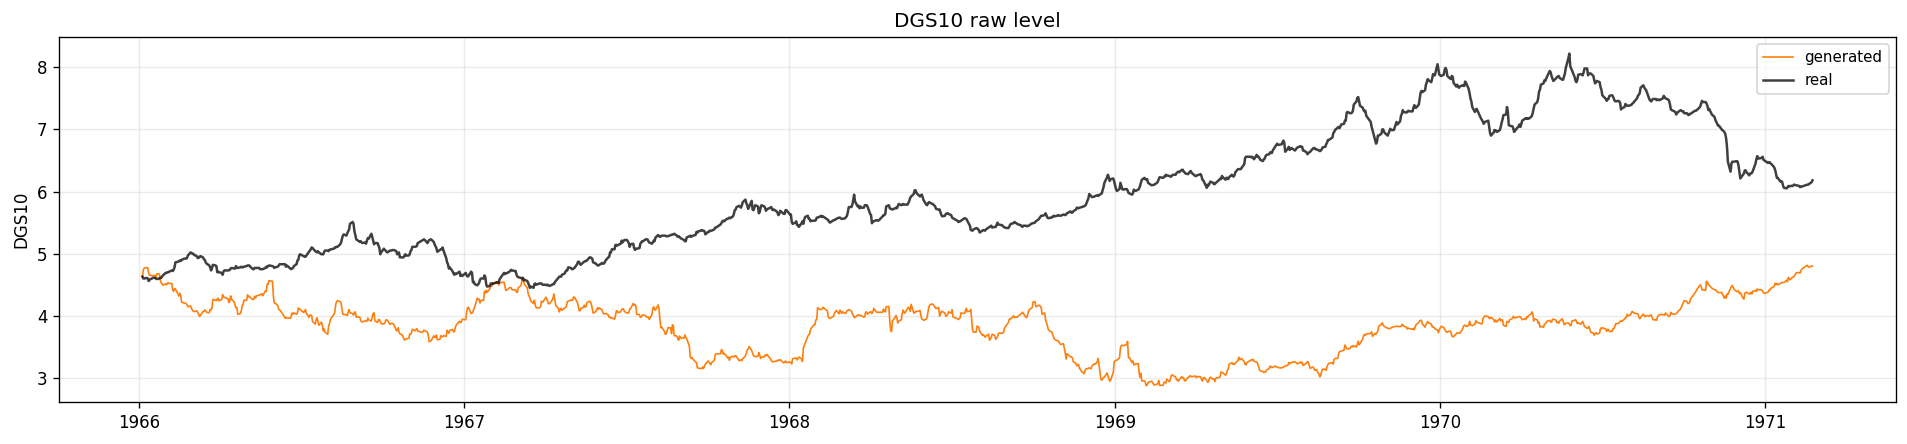

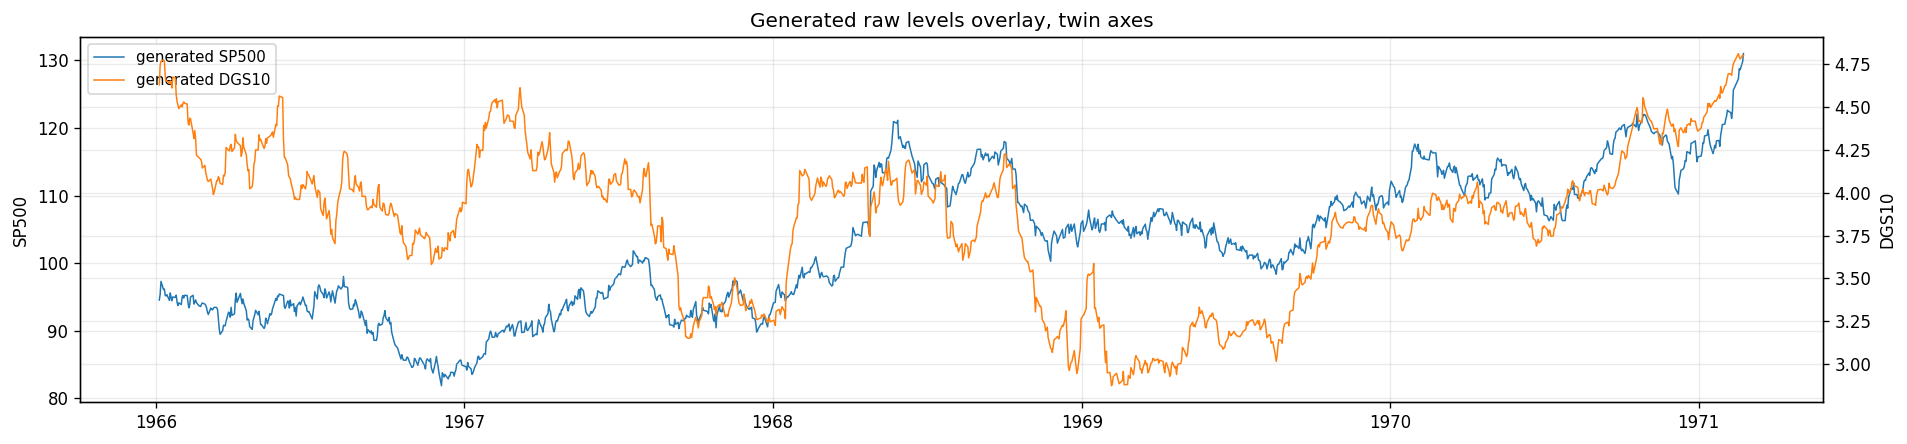

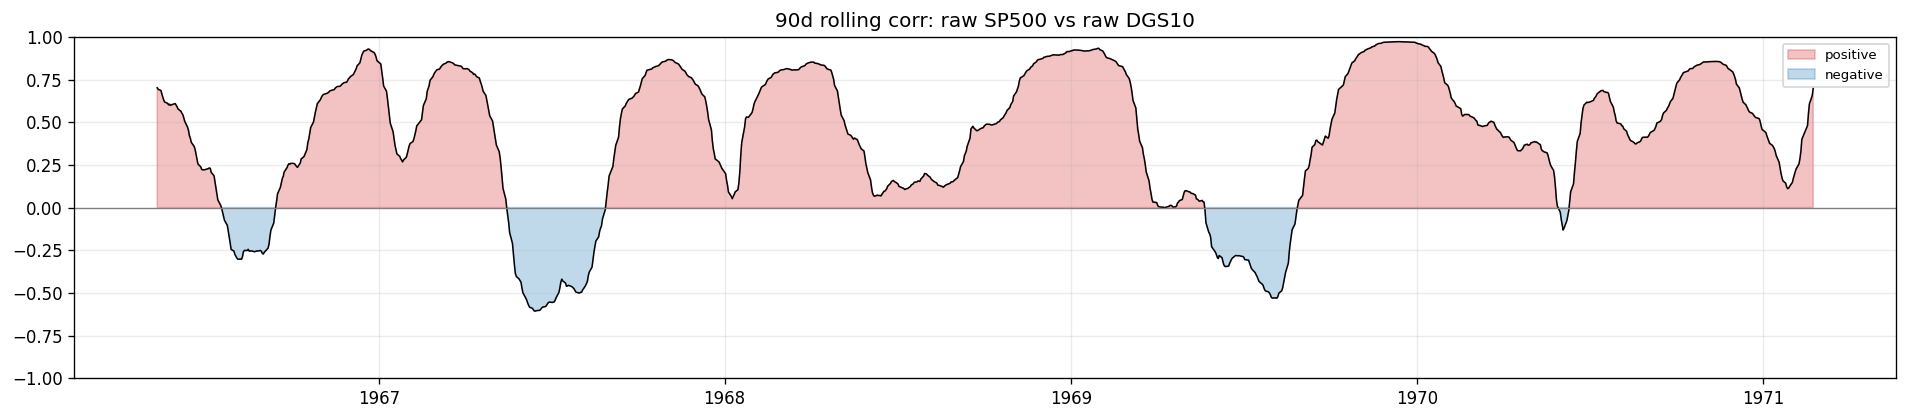

In [34]:
plot_raw_path_overview(df5, f"{SEED}: 5y chunk {CHUNK} raw path")


## 選択 seed の12チャンク一覧

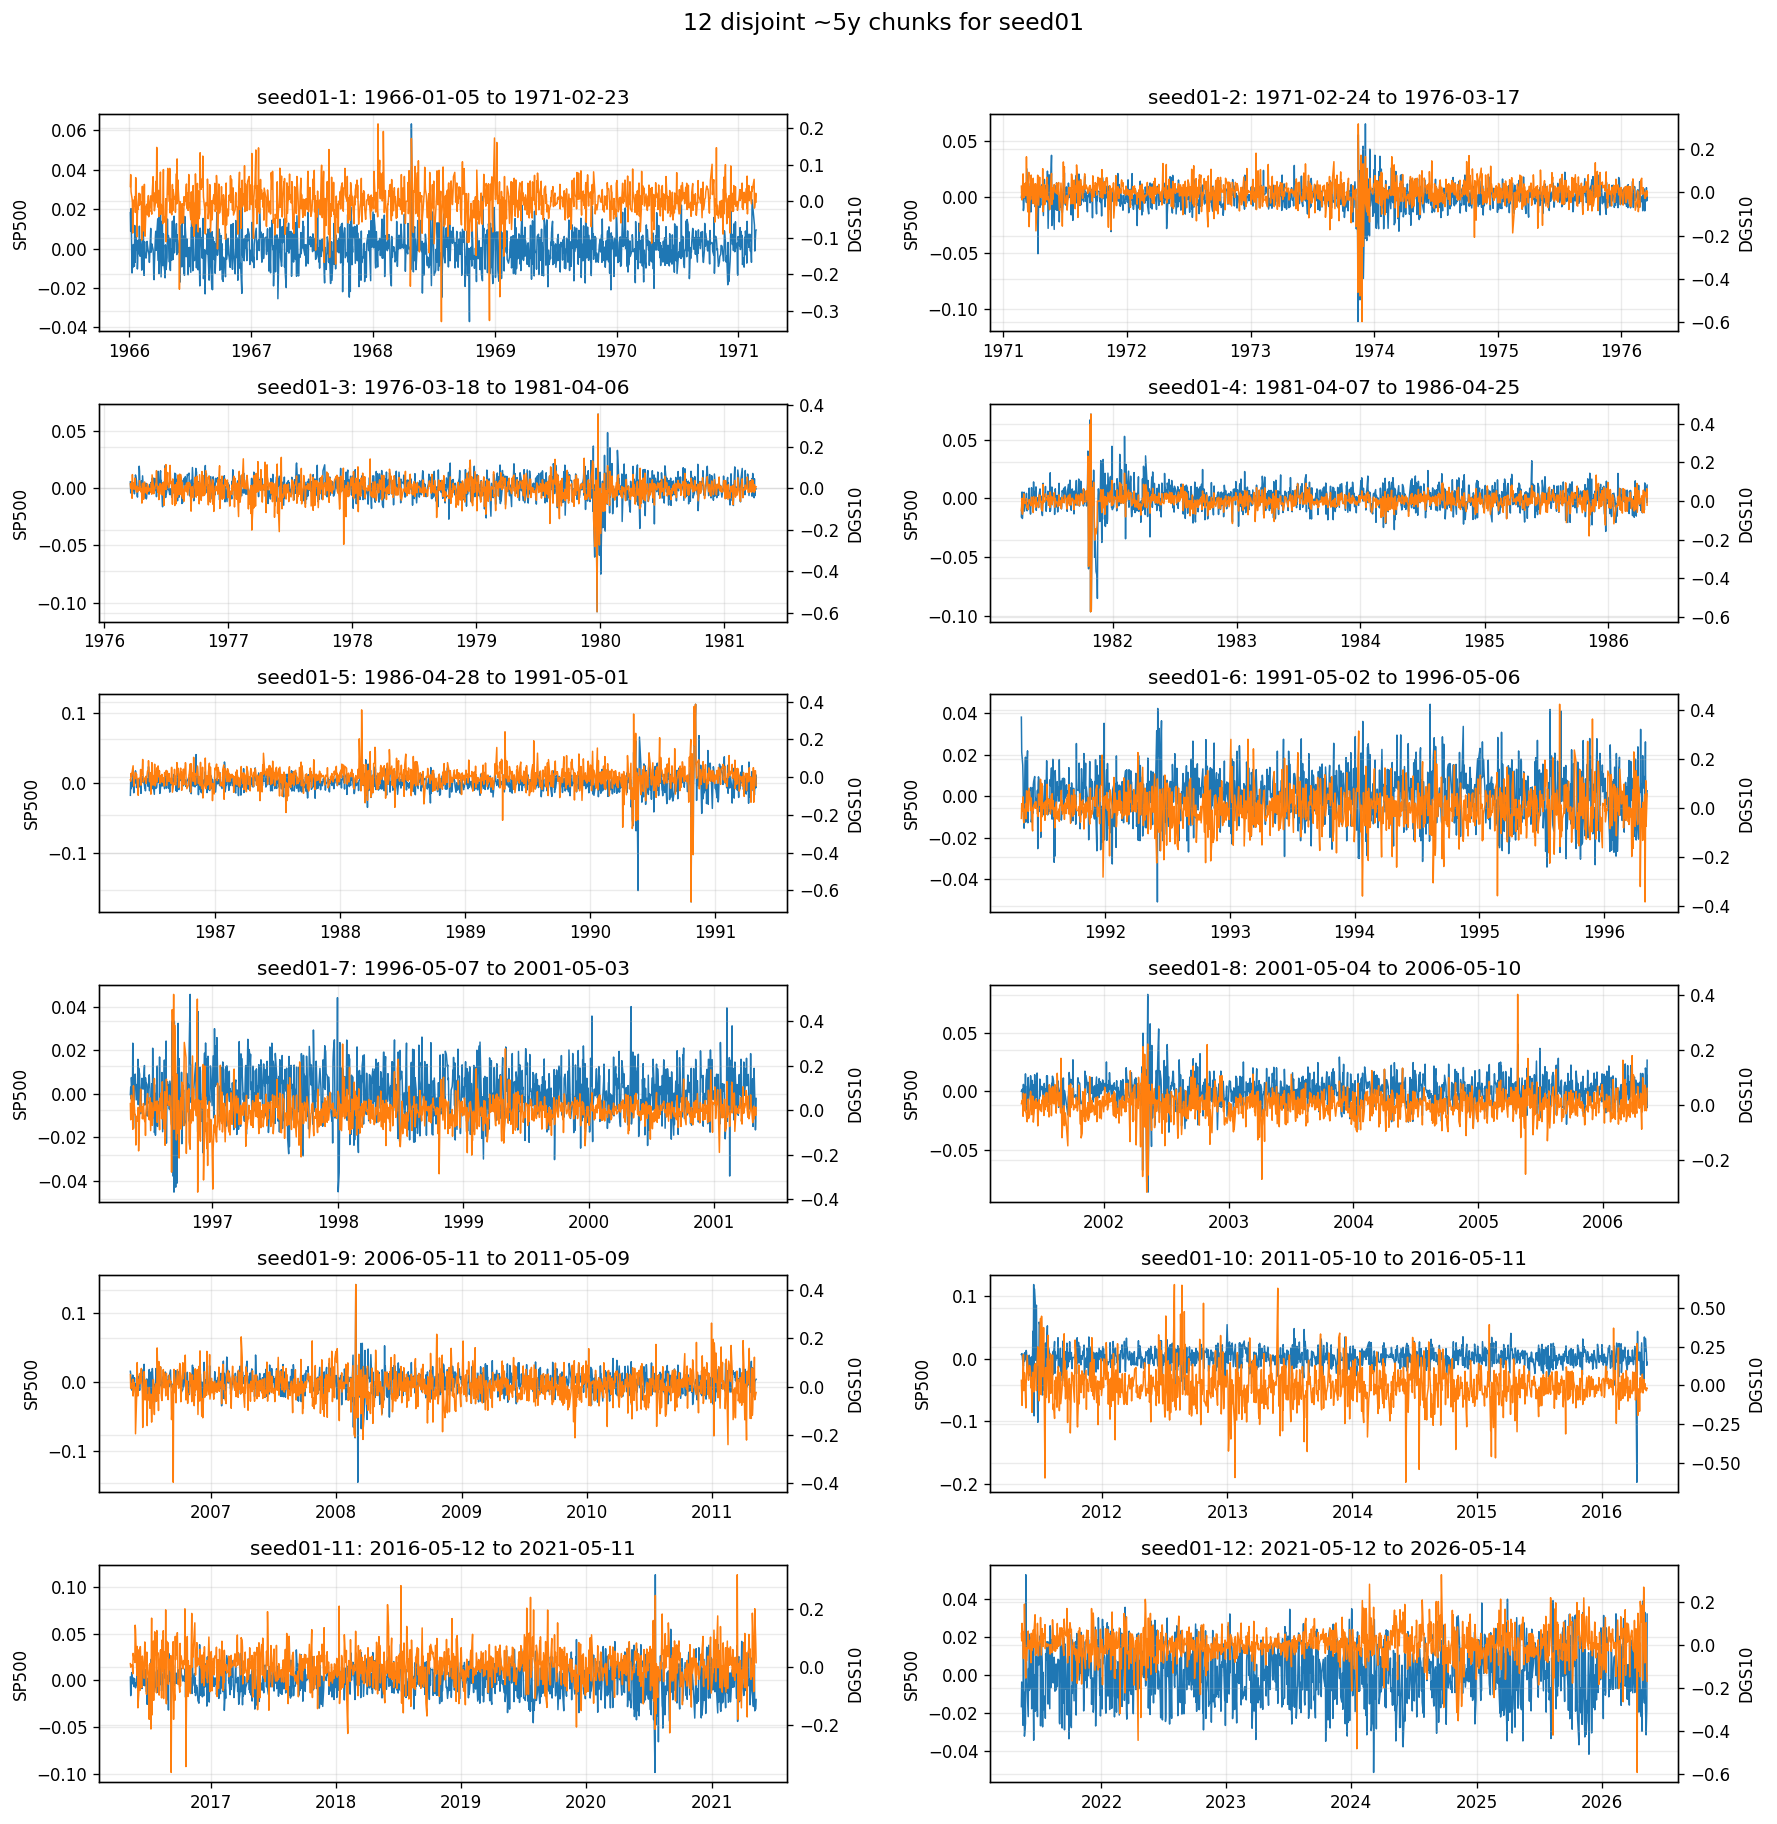

In [35]:

fig, axes = plt.subplots(6, 2, figsize=(15, 15), sharex=False)
axes = axes.ravel()
for chunk in range(1, 13):
    p = PATH5 / f"generated_paths_{SEED}-{chunk}.csv"
    d = pd.read_csv(p, parse_dates=["Date"])
    ax = axes[chunk-1]
    ax2 = ax.twinx()
    ax.plot(d["Date"], d["sp500"], color="tab:blue", lw=0.9, label="SP500")
    ax2.plot(d["Date"], d["DGS10"], color="tab:orange", lw=0.9, label="DGS10")
    ax.set_title(f"{SEED}-{chunk}: {d['Date'].iloc[0].date()} to {d['Date'].iloc[-1].date()}")
    ax.set_ylabel("SP500")
    ax2.set_ylabel("DGS10")
fig.suptitle(f"12 disjoint ~5y chunks for {SEED}", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


## 分割メタデータ

In [36]:

meta_path = ROOT / "split_metadata.csv"
if meta_path.exists():
    metadata = pd.read_csv(meta_path)
    display(metadata.head(20))
else:
    print("split_metadata.csv not found")


,seed,seed_label,chunk,rows,start_date,end_date,path
0,1,seed01,1,1241,1966-01-05,1971-02-23,5y_paths/generated_paths_seed01-1.csv
1,1,seed01,2,1241,1971-02-24,1976-03-17,5y_paths/generated_paths_seed01-2.csv
2,1,seed01,3,1240,1976-03-18,1981-04-06,5y_paths/generated_paths_seed01-3.csv
3,1,seed01,4,1240,1981-04-07,1986-04-25,5y_paths/generated_paths_seed01-4.csv
4,1,seed01,5,1240,1986-04-28,1991-05-01,5y_paths/generated_paths_seed01-5.csv
5,1,seed01,6,1240,1991-05-02,1996-05-06,5y_paths/generated_paths_seed01-6.csv
6,1,seed01,7,1240,1996-05-07,2001-05-03,5y_paths/generated_paths_seed01-7.csv
7,1,seed01,8,1240,2001-05-04,2006-05-10,5y_paths/generated_paths_seed01-8.csv
8,1,seed01,9,1240,2006-05-11,2011-05-09,5y_paths/generated_paths_seed01-9.csv
9,1,seed01,10,1240,2011-05-10,2016-05-11,5y_paths/generated_paths_seed01-10.csv
